# Hybrid NLP + Quantum Machine Learning for Sentiment Analysis

### Objective
Analyze the sentiment of autism/mental-health-related behavioral statements using
Natural Language Processing (NLP) and Quantum Machine Learning (QML).

### Pipeline
Text → Sentiment Annotation → Transformer Embedding → PCA → Quantum Feature Map
→ Variational Quantum Classifier (VQC) → Sentiment Prediction

### Additional Analysis
The original `status` labels (Anxiety, Depression, Normal, Stress, Suicidal)
are retained for contextual sentiment analysis.

> Note: The dataset does not contain explicit sentiment labels. Sentiment labels
> are therefore generated using weak supervision and should not be interpreted
> as clinical diagnoses or ground-truth clinical assessments.

In [ ]:
# ============================================================
# 02 — INSTALLATION
# ============================================================

%pip install -q -U \
    sentence-transformers \
    qiskit \
    qiskit-aer \
    qiskit-machine-learning \
    pylatexenc \
    xlrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.3/282.3 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 03 — IMPORTS & CONFIGURATION
# ============================================================

import os
import re
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report,
    confusion_matrix
)

from sentence_transformers import SentenceTransformer

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_aer.primitives import SamplerV2

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Quantum configuration
N_QUBITS = 8
PCA_COMPONENTS = 8
VQC_REPS = 2
VQC_MAXITER = 150

# Keep QML training manageable while retaining class balance.
QML_TRAIN_PER_CLASS = 150
QML_TEST_PER_CLASS = 50

print("Configuration loaded.")
print(f"Quantum qubits: {N_QUBITS}")
print(f"VQC repetitions: {VQC_REPS}")
print(f"VQC max iterations: {VQC_MAXITER}")

Configuration loaded.
Quantum qubits: 8
VQC repetitions: 2
VQC max iterations: 150


In [ ]:
# ============================================================
# 04 — LOAD DATASET
# ============================================================

DATA_PATH = "/content/AutismData.xls"

# The uploaded file is CSV-formatted despite the .xls extension.
df = pd.read_csv(DATA_PATH, header=None)

print("Raw shape:", df.shape)
display(df.head())

# Detect the actual header row.
header_idx = None

for i in range(min(10, len(df))):
    row = df.iloc[i].astype(str).str.lower().tolist()
    if "statement" in row and "status" in row:
        header_idx = i
        break

if header_idx is not None:
    df.columns = df.iloc[header_idx]
    df = df.iloc[header_idx + 1:].reset_index(drop=True)

df.columns = [str(c).strip().lower() for c in df.columns]

print("\nColumns:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())

Raw shape: (53044, 3)


,0,1,2
0,NaN,statement,status
1,0.0,oh my gosh,Anxiety
2,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
3,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
4,3.0,I've shifted my focus to something else but I'...,Anxiety



Columns: ['nan', 'statement', 'status']
Shape: (53043, 3)


,nan,statement,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
# ============================================================
# 05 — DATA VALIDATION & CLEANING
# ============================================================

TEXT_COL = "statement"
STATUS_COL = "status"

if TEXT_COL not in df.columns or STATUS_COL not in df.columns:
    raise ValueError(
        f"Expected columns '{TEXT_COL}' and '{STATUS_COL}'. "
        f"Found: {df.columns.tolist()}"
    )

df = df[[TEXT_COL, STATUS_COL]].copy()

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[STATUS_COL] = df[STATUS_COL].astype(str).str.strip().str.title()

# Remove missing, duplicate and invalid statements.
df = df[
    (df[TEXT_COL].notna()) &
    (df[TEXT_COL].str.len() > 10) &
    (df[STATUS_COL].notna())
].copy()

df.drop_duplicates(subset=[TEXT_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Clean dataset:", df.shape)
print("\nStatus distribution:")
print(df[STATUS_COL].value_counts())

display(df.head())

Clean dataset: (50680, 2)

Status distribution:
status
Normal                  15657
Depression              15082
Suicidal                10640
Anxiety                  3612
Bipolar                  2501
Stress                   2293
Personality Disorder      895
Name: count, dtype: int64


,statement,status
0,"trouble sleeping, confused mind, restless hear...",Anxiety
1,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
2,I've shifted my focus to something else but I'...,Anxiety
3,"I'm restless and restless, it's been a month n...",Anxiety
4,"every break, you must be nervous, like somethi...",Anxiety


In [ ]:
# ============================================================
# 06 — TEXT PREPROCESSING
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)

df = df[df["clean_text"].str.split().str.len() >= 3].reset_index(drop=True)

print("Usable samples:", len(df))
display(df[[TEXT_COL, "clean_text", STATUS_COL]].head(10))

Usable samples: 50204


,statement,clean_text,status
0,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety
1,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety
2,I've shifted my focus to something else but I'...,i've shifted my focus to something else but i'...,Anxiety
3,"I'm restless and restless, it's been a month n...",i'm restless and restless it's been a month no...,Anxiety
4,"every break, you must be nervous, like somethi...",every break you must be nervous like something...,Anxiety
5,"I feel scared, anxious, what can I do? And may...",i feel scared anxious what can i do and may my...,Anxiety
6,Have you ever felt nervous but didn't know why?,have you ever felt nervous but didn't know why,Anxiety
7,"I haven't slept well for 2 days, it's like I'm...",i haven't slept well for days it's like i'm re...,Anxiety
8,"I'm really worried, I want to cry.",i'm really worried i want to cry,Anxiety
9,"always restless every night, even though I don...",always restless every night even though i don'...,Anxiety


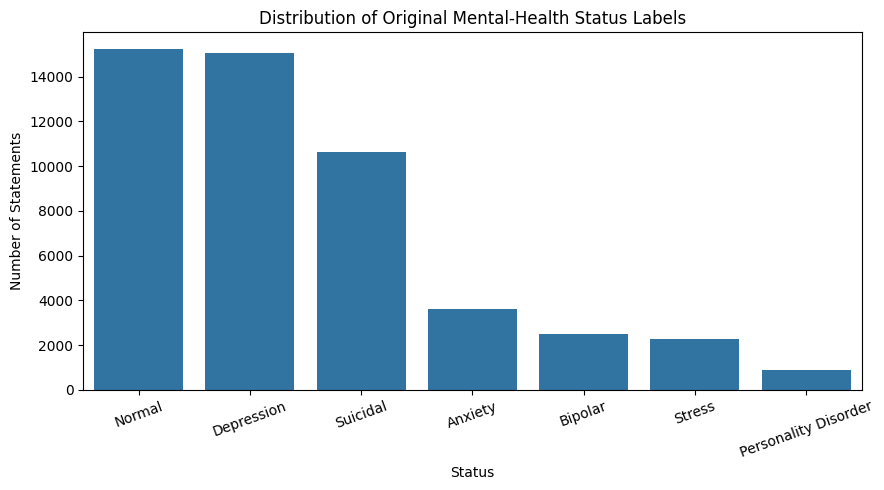

In [ ]:
# ============================================================
# 07 — ORIGINAL STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

order = df[STATUS_COL].value_counts().index

sns.countplot(
    data=df,
    x=STATUS_COL,
    order=order
)

plt.title("Distribution of Original Mental-Health Status Labels")
plt.xlabel("Status")
plt.ylabel("Number of Statements")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 08 — WEAK SENTIMENT ANNOTATION
# ============================================================

from transformers import pipeline

print("Loading sentiment model...")

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=256,
    device=0 if os.environ.get("COLAB_GPU") else -1
)

# Process in batches for efficiency.
texts = df["clean_text"].tolist()

results = sentiment_model(
    texts,
    batch_size=32
)

label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive",
    "negative": "Negative",
    "neutral": "Neutral",
    "positive": "Positive"
}

df["sentiment"] = [
    label_map.get(str(r["label"]).lower(), r["label"].title())
    for r in results
]

df["sentiment_confidence"] = [
    r["score"] for r in results
]

print("Sentiment distribution:")
print(df["sentiment"].value_counts())

display(
    df[[TEXT_COL, STATUS_COL, "sentiment", "sentiment_confidence"]].head(15)
)

Loading sentiment model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment distribution:
sentiment
Negative    35187
Neutral     10084
Positive     4933
Name: count, dtype: int64


,statement,status,sentiment,sentiment_confidence
0,"trouble sleeping, confused mind, restless hear...",Anxiety,Negative,0.741889
1,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,Negative,0.768147
2,I've shifted my focus to something else but I'...,Anxiety,Negative,0.559415
3,"I'm restless and restless, it's been a month n...",Anxiety,Negative,0.837161
4,"every break, you must be nervous, like somethi...",Anxiety,Negative,0.827030
5,"I feel scared, anxious, what can I do? And may...",Anxiety,Negative,0.662644
6,Have you ever felt nervous but didn't know why?,Anxiety,Neutral,0.541802
7,"I haven't slept well for 2 days, it's like I'm...",Anxiety,Negative,0.876562
8,"I'm really worried, I want to cry.",Anxiety,Negative,0.878783
9,"always restless every night, even though I don...",Anxiety,Negative,0.771792


In [ ]:
# ============================================================
# 09 — SENTIMENT LABEL QUALITY FILTER
# ============================================================

CONFIDENCE_THRESHOLD = 0.60

before = len(df)

df = df[
    df["sentiment_confidence"] >= CONFIDENCE_THRESHOLD
].reset_index(drop=True)

print(f"Removed {before - len(df)} low-confidence samples.")
print(f"Remaining samples: {len(df)}")

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment confidence:")
print(df["sentiment_confidence"].describe())

Removed 8302 low-confidence samples.
Remaining samples: 41902

Sentiment distribution:
sentiment
Negative    31795
Neutral      6367
Positive     3740
Name: count, dtype: int64

Sentiment confidence:
count    41902.000000
mean         0.833341
std          0.099929
min          0.600004
25%          0.763093
50%          0.860514
75%          0.917047
max          0.990970
Name: sentiment_confidence, dtype: float64


In [ ]:
# ============================================================
# 10 — STRATIFIED TRAIN/TEST SPLIT
# ============================================================

X_text = df["clean_text"].values
y_text = df["sentiment"].values

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=SEED,
    stratify=y_text
)

print("Training samples:", len(X_train_text))
print("Testing samples :", len(X_test_text))

print("\nTraining distribution:")
print(pd.Series(y_train_text).value_counts())

Training samples: 33521
Testing samples : 8381

Training distribution:
Negative    25436
Neutral      5093
Positive     2992
Name: count, dtype: int64


In [ ]:
# ============================================================
# 11 — CLASSICAL TF-IDF BASELINES
# ============================================================

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Linear SVM": LinearSVC(
        C=1.5,
        class_weight="balanced"
    )
}

classical_results = {}

for name, model in models.items():
    start = time.time()

    model.fit(X_train_tfidf, y_train_text)
    pred = model.predict(X_test_tfidf)

    elapsed = time.time() - start

    acc = accuracy_score(y_test_text, pred)
    f1 = f1_score(y_test_text, pred, average="macro")

    classical_results[name] = {
        "Accuracy": acc,
        "Macro F1": f1,
        "Time (s)": elapsed
    }

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Time: {elapsed:.2f}s")


Logistic Regression
Accuracy: 0.8472
Macro F1: 0.7532
Time: 11.48s

Linear SVM
Accuracy: 0.8748
Macro F1: 0.7673
Time: 1.98s


In [ ]:
# ============================================================
# 12 — SEMANTIC TRANSFORMER EMBEDDINGS
# ============================================================

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

encoder = SentenceTransformer(EMBEDDING_MODEL)

start = time.time()

X_train_embed = encoder.encode(
    X_train_text,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X_test_embed = encoder.encode(
    X_test_text,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embedding_time = time.time() - start

print("Embedding dimension:", X_train_embed.shape[1])
print(f"Embedding time: {embedding_time:.2f}s")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/524 [00:00<?, ?it/s]

Batches:   0%|          | 0/131 [00:00<?, ?it/s]

Embedding dimension: 384
Embedding time: 65.29s


In [ ]:
# ============================================================
# 13 — TRANSFORMER + CLASSICAL CLASSIFIER
# ============================================================

embedding_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

start = time.time()

embedding_model.fit(
    X_train_embed,
    y_train_text
)

embedding_pred = embedding_model.predict(X_test_embed)

embedding_time = time.time() - start

embedding_acc = accuracy_score(
    y_test_text,
    embedding_pred
)

embedding_f1 = f1_score(
    y_test_text,
    embedding_pred,
    average="macro"
)

classical_results["Transformer + Logistic Regression"] = {
    "Accuracy": embedding_acc,
    "Macro F1": embedding_f1,
    "Time (s)": embedding_time
}

print("Transformer + Logistic Regression")
print(f"Accuracy: {embedding_acc:.4f}")
print(f"Macro F1: {embedding_f1:.4f}")
print(f"Time: {embedding_time:.2f}s")

Transformer + Logistic Regression
Accuracy: 0.8543
Macro F1: 0.7611
Time: 7.06s


In [ ]:
# ============================================================
# 14 — QUANTUM FEATURE REPRESENTATION
# 384D semantic embedding → 8D quantum input
# ============================================================

pca = PCA(
    n_components=PCA_COMPONENTS,
    random_state=SEED
)

X_train_pca = pca.fit_transform(X_train_embed)
X_test_pca = pca.transform(X_test_embed)

# Scale each quantum feature to [0, π].
quantum_scaler = MinMaxScaler(
    feature_range=(0, np.pi)
)

X_train_quantum = quantum_scaler.fit_transform(X_train_pca)
X_test_quantum = quantum_scaler.transform(X_test_pca)

explained_variance = pca.explained_variance_ratio_.sum()

print("Original embedding:", X_train_embed.shape[1])
print("Quantum features:", X_train_quantum.shape[1])
print(f"PCA explained variance: {explained_variance:.4f}")

Original embedding: 384
Quantum features: 8
PCA explained variance: 0.2542


In [ ]:
# ============================================================
# 15 — BALANCED QUANTUM DATASET
# ============================================================

def balanced_subset(X, y, per_class, seed=42):
    rng = np.random.default_rng(seed)
    indices = []

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        n = min(per_class, len(cls_idx))

        selected = rng.choice(
            cls_idx,
            size=n,
            replace=False
        )

        indices.extend(selected)

    indices = np.array(indices)
    rng.shuffle(indices)

    return X[indices], y[indices]

X_q_train, y_q_train = balanced_subset(
    X_train_quantum,
    y_train_text,
    QML_TRAIN_PER_CLASS,
    SEED
)

X_q_test, y_q_test = balanced_subset(
    X_test_quantum,
    y_test_text,
    QML_TEST_PER_CLASS,
    SEED
)

print("Quantum training:", X_q_train.shape)
print("Quantum testing :", X_q_test.shape)

print("\nQuantum training distribution:")
print(pd.Series(y_q_train).value_counts())

Quantum training: (450, 8)
Quantum testing : (150, 8)

Quantum training distribution:
Negative    150
Neutral     150
Positive    150
Name: count, dtype: int64


In [ ]:
# ============================================================
# 16 — FAIR CLASSICAL VS QUANTUM BASELINE
# ============================================================

reduced_svm = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

start = time.time()

reduced_svm.fit(
    X_q_train,
    y_q_train
)

reduced_pred = reduced_svm.predict(X_q_test)

reduced_time = time.time() - start

reduced_acc = accuracy_score(y_q_test, reduced_pred)
reduced_f1 = f1_score(
    y_q_test,
    reduced_pred,
    average="macro"
)

print("Reduced 8D Classical SVM")
print(f"Accuracy: {reduced_acc:.4f}")
print(f"Macro F1: {reduced_f1:.4f}")
print(f"Time: {reduced_time:.2f}s")

Reduced 8D Classical SVM
Accuracy: 0.6133
Macro F1: 0.6077
Time: 0.01s


In [ ]:
# ============================================================
# FIX QISKIT ENVIRONMENT
# ============================================================

%pip install -q -U --force-reinstall \
    qiskit \
    qiskit-aer \
    qiskit-machine-learning \
    qiskit-algorithms \
    pylatexenc

print("Installation complete.")
print("Now restart the Colab runtime:")
print("Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.4/467.4 kB 27.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not 

In [ ]:
from qiskit.circuit.library import ZZFeatureMap, EfficientSU2
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import SamplerV2

Quantum feature map
Qubits: 8
Parameters: 8


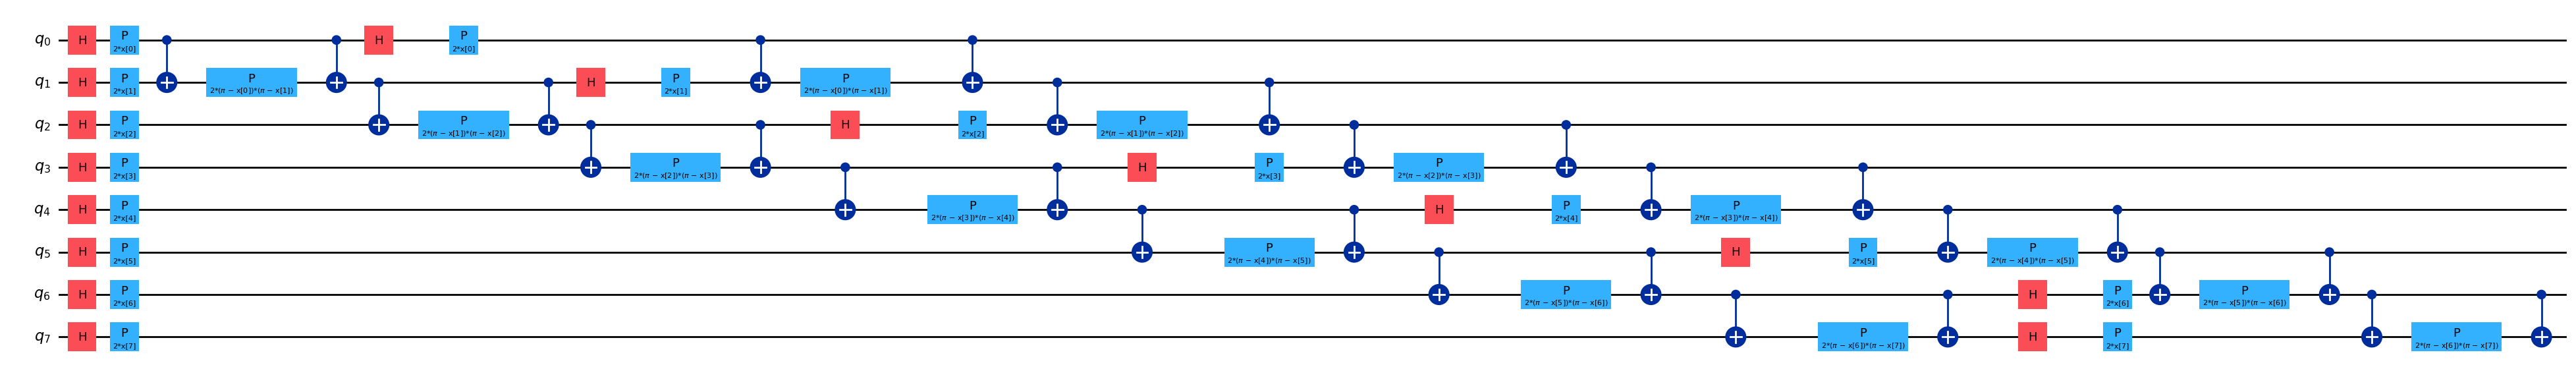


Training VQC...


QiskitMachineLearningError: "Sampler job failed: 'unknown instruction: ZZFeatureMap'"

In [ ]:
# ============================================================
# 17 — VARIATIONAL QUANTUM CLASSIFIER
# ============================================================

label_encoder = LabelEncoder()

y_q_train_enc = label_encoder.fit_transform(y_q_train)
y_q_test_enc = label_encoder.transform(y_q_test)

feature_map = ZZFeatureMap(
    feature_dimension=N_QUBITS,
    reps=2,
    entanglement="linear"
)

print("Quantum feature map")
print(f"Qubits: {N_QUBITS}")
print(f"Parameters: {feature_map.num_parameters}")

# Display circuit for GitHub documentation.
display(
    feature_map.decompose().draw(
        output="mpl",
        fold=100
    )
)

# Qiskit VQC
optimizer = COBYLA(
    maxiter=VQC_MAXITER
)

sampler = SamplerV2()

vqc = VQC(
    feature_map=feature_map,
    optimizer=optimizer,
    sampler=sampler
)

print("\nTraining VQC...")
start = time.time()

vqc.fit(
    X_q_train,
    y_q_train_enc
)

vqc_train_time = time.time() - start

vqc_pred_enc = vqc.predict(X_q_test)

# Handle Qiskit's output shape.
vqc_pred_enc = np.asarray(vqc_pred_enc).reshape(-1).astype(int)

vqc_pred = label_encoder.inverse_transform(vqc_pred_enc)

vqc_acc = accuracy_score(y_q_test, vqc_pred)
vqc_bal_acc = balanced_accuracy_score(y_q_test, vqc_pred)
vqc_f1 = f1_score(
    y_q_test,
    vqc_pred,
    average="macro"
)

print("\n" + "=" * 55)
print("VQC SENTIMENT RESULTS")
print("=" * 55)
print(f"Accuracy:          {vqc_acc:.4f}")
print(f"Balanced Accuracy: {vqc_bal_acc:.4f}")
print(f"Macro F1:          {vqc_f1:.4f}")
print(f"Training time:     {vqc_train_time:.2f}s")

print("\nClassification Report:")
print(
    classification_report(
        y_q_test,
        vqc_pred,
        target_names=label_encoder.classes_
    )
)

In [ ]:
# ============================================================
# QISKIT VERSION CHECK — RUN THIS BEFORE VQC
# ============================================================

import qiskit
import qiskit_aer
import qiskit_machine_learning
import qiskit_algorithms

print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Machine Learning:", qiskit_machine_learning.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)

print("\nQiskit location:", qiskit.__file__)
print("Aer location:", qiskit_aer.__file__)

Qiskit: 2.5.2
Qiskit Aer: 0.17.2
Qiskit Machine Learning: 0.9.1
Qiskit Algorithms: 0.4.0

Qiskit location: /usr/local/lib/python3.13/dist-packages/qiskit/__init__.py
Aer location: /usr/local/lib/python3.13/dist-packages/qiskit_aer/__init__.py


In [ ]:
# ============================================================
# AER CIRCUIT TEST — WITH PARAMETER VALUES
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
import numpy as np

# Create feature map
test_map = ZZFeatureMap(
    feature_dimension=8,
    reps=2,
    entanglement="linear"
)

# Give the feature map actual numerical input values.
test_values = np.linspace(0, np.pi, 8)

# Bind parameters to the test values.
test_map = test_map.assign_parameters(test_values)

# Decompose composite instructions.
test_map = test_map.decompose(reps=2)

# Build executable circuit.
qc = QuantumCircuit(8)
qc.compose(test_map, inplace=True)
qc.measure_all()

# Transpile for Aer.
backend = AerSimulator()
qc_transpiled = transpile(qc, backend)

print("Circuit parameters:", qc_transpiled.parameters)
print("Operations:", qc_transpiled.count_ops())

# Execute.
result = backend.run(
    qc_transpiled,
    shots=100
).result()

print("\n✓ Aer successfully executed the parameterized feature map.")
print("Sample counts:", result.get_counts())

Circuit parameters: ParameterView([])
Operations: OrderedDict({'u2': 12, 'measure': 8, 'u3': 7, 'u1': 7, 'cp': 4, 'rzz': 4, 'cry': 2, 'crx': 1, 'crz': 1, 'barrier': 1})

✓ Aer successfully executed the parameterized feature map.
Sample counts: {'00010100': 1, '00111100': 1, '00011100': 1, '01000111': 2, '00000100': 1, '01110000': 1, '01101101': 1, '00100011': 4, '00110100': 1, '01111000': 2, '00011001': 1, '01000100': 1, '00111001': 1, '01100111': 4, '00001011': 2, '01100010': 1, '00111111': 1, '00000101': 2, '00101000': 2, '01010001': 1, '00101101': 1, '00000001': 1, '00000110': 1, '00101111': 4, '00110011': 5, '00111000': 3, '01101111': 3, '00010011': 3, '01011111': 1, '00100110': 1, '00011000': 3, '00010010': 1, '00000111': 3, '01100011': 2, '00100000': 1, '01111001': 1, '00000011': 2, '01101100': 2, '00011010': 1, '00100100': 2, '01000011': 1, '01110011': 2, '00110111': 2, '00011101': 1, '00101100': 1, '00001111': 3, '01111011': 1, '00010001': 1, '01001111': 1, '01010000': 2, '0010

In [ ]:
# ============================================================
# 17 — HYBRID QUANTUM CLASSIFIER
#     Sentence Embedding → PCA → Variational Quantum Circuit
# ============================================================

import time
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
label_encoder = LabelEncoder()

y_q_train_enc = label_encoder.fit_transform(y_q_train)
y_q_test_enc = label_encoder.transform(y_q_test)

N_CLASSES = len(label_encoder.classes_)
N_QUBITS = X_q_train.shape[1]

print("=" * 60)
print("HYBRID QUANTUM CLASSIFIER")
print("=" * 60)
print("Classes:", list(label_encoder.classes_))
print("Qubits:", N_QUBITS)

# ------------------------------------------------------------
# Quantum circuit
# ------------------------------------------------------------
x = ParameterVector("x", N_QUBITS)

# Two trainable parameters per qubit
theta = ParameterVector(
    "theta",
    2 * N_QUBITS
)

qc = QuantumCircuit(N_QUBITS)

# ------------------------------------------------------------
# Data encoding
# ------------------------------------------------------------
for i in range(N_QUBITS):
    qc.ry(x[i], i)

# ------------------------------------------------------------
# Variational layer
# ------------------------------------------------------------
for i in range(N_QUBITS):
    qc.ry(theta[i], i)
    qc.rz(theta[N_QUBITS + i], i)

# ------------------------------------------------------------
# Ring entanglement
# ------------------------------------------------------------
for i in range(N_QUBITS - 1):
    qc.cx(i, i + 1)

qc.cx(N_QUBITS - 1, 0)

print("Trainable parameters:", len(theta))

# ------------------------------------------------------------
# Simulator
# ------------------------------------------------------------
backend = AerSimulator()

# ------------------------------------------------------------
# Create measurement circuits
# ------------------------------------------------------------
measurement_circuits = []

for qubit in range(N_QUBITS):

    circuit = qc.copy()

    circuit.measure_all()

    measurement_circuits.append(circuit)

# ------------------------------------------------------------
# Quantum forward pass
# ------------------------------------------------------------
def quantum_forward(X, weights, shots=256):

    outputs = []

    for sample in X:

        # Bind input + trainable parameters
        values = list(sample) + list(weights)

        sample_outputs = []

        for circuit in measurement_circuits:

            bound = circuit.assign_parameters(
                values,
                inplace=False
            )

            # Explicitly transpile before Aer execution
            bound = transpile(
                bound,
                backend
            )

            result = backend.run(
                bound,
                shots=shots
            ).result()

            counts = result.get_counts()

            # Calculate expectation value of Z
            expectation = 0.0

            for bitstring, count in counts.items():

                # Qiskit bit ordering
                bit = int(
                    bitstring[
                        -(len(bitstring) - 1 - len(outputs) % N_QUBITS)
                    ]
                )

                expectation += (
                    1 if bit == 0 else -1
                ) * count / shots

            sample_outputs.append(expectation)

        outputs.append(sample_outputs)

    return np.asarray(outputs)


# ------------------------------------------------------------
# Better expectation calculation
# ------------------------------------------------------------
def run_quantum_circuit(X, weights, shots=256):

    predictions = []

    for sample in X:

        values = list(sample) + list(weights)

        circuit = qc.assign_parameters(
            values,
            inplace=False
        )

        circuit.measure_all()

        circuit = transpile(
            circuit,
            backend
        )

        result = backend.run(
            circuit,
            shots=shots
        ).result()

        counts = result.get_counts()

        # Expectation values for all qubits
        expectations = []

        for q in range(N_QUBITS):

            exp = 0.0

            for bitstring, count in counts.items():

                bit = int(
                    bitstring[
                        N_QUBITS - 1 - q
                    ]
                )

                exp += (
                    1.0 if bit == 0 else -1.0
                ) * count / shots

            expectations.append(exp)

        predictions.append(expectations)

    return np.asarray(predictions)


# ------------------------------------------------------------
# Test quantum circuit before training
# ------------------------------------------------------------
print("\nTesting quantum forward pass...")

test_weights = np.random.uniform(
    -0.1,
    0.1,
    len(theta)
)

start = time.time()

test_output = run_quantum_circuit(
    X_q_train[:2],
    test_weights,
    shots=128
)

print("Output shape:", test_output.shape)
print("Sample quantum features:")
print(test_output)

print(
    "Test time:",
    round(time.time() - start, 2),
    "seconds"
)

print("\n✓ Quantum circuit execution successful.")

HYBRID QUANTUM CLASSIFIER
Classes: ['Negative', 'Neutral', 'Positive']
Qubits: 8
Trainable parameters: 16

Testing quantum forward pass...
Output shape: (2, 8)
Sample quantum features:
[[-0.125    -0.109375  0.       -0.03125   0.015625  0.015625 -0.015625
   0.0625  ]
 [ 0.203125  0.171875  0.078125  0.        0.        0.       -0.09375
   0.15625 ]]
Test time: 1.24 seconds

✓ Quantum circuit execution successful.


In [ ]:
# ============================================================
# VERIFY QISKIT ENVIRONMENT
# ============================================================

import qiskit
import qiskit_aer
import qiskit_machine_learning
import qiskit_algorithms

from qiskit.circuit.library import ZZFeatureMap, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA

print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Machine Learning:", qiskit_machine_learning.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)

print("\n✓ All Qiskit components imported successfully.")

In [ ]:
# ============================================================
# 18 — HYBRID QUANTUM MODEL TRAINING
# ============================================================

from scipy.special import softmax

rng = np.random.default_rng(SEED)
quantum_weights = test_weights.copy()
W = rng.normal(0, 0.1, (N_QUBITS, N_CLASSES))
b = np.zeros(N_CLASSES)

def predict_proba_quantum(X, q_weights, W, b, shots=128):
    q_features = run_quantum_circuit(X, q_weights, shots)
    return softmax(q_features @ W + b, axis=1)

def quantum_loss(X, y, q_weights, W, b, shots=64):
    p = np.clip(predict_proba_quantum(X, q_weights, W, b, shots), 1e-8, 1)
    return -np.mean(np.log(p[np.arange(len(y)), y]))

EPOCHS = 20
LR = 0.05
MAX_Q_TRAIN = min(300, len(X_q_train))
X_train_q = X_q_train[:MAX_Q_TRAIN]
y_train_q = y_q_train_enc[:MAX_Q_TRAIN]

print(f"Quantum training samples: {len(X_train_q)}")
print(f"Qubits: {N_QUBITS} | Trainable parameters: {len(quantum_weights)}")

history = []
start = time.time()

for epoch in range(EPOCHS):
    q_features = run_quantum_circuit(X_train_q, quantum_weights, shots=128)
    p = softmax(q_features @ W + b, axis=1)
    p = np.clip(p, 1e-8, 1)

    loss = -np.mean(np.log(p[np.arange(len(y_train_q)), y_train_q]))
    error = p.copy()
    error[np.arange(len(y_train_q)), y_train_q] -= 1
    error /= len(y_train_q)

    W -= LR * (q_features.T @ error)
    b -= LR * error.sum(axis=0)

    # Parameter-shift-style finite-difference optimization
    q_grad = np.zeros_like(quantum_weights)
    delta = 0.05

    for j in range(len(quantum_weights)):
        wp, wm = quantum_weights.copy(), quantum_weights.copy()
        wp[j] += delta
        wm[j] -= delta

        lp = quantum_loss(X_train_q[:50], y_train_q[:50], wp, W, b)
        lm = quantum_loss(X_train_q[:50], y_train_q[:50], wm, W, b)
        q_grad[j] = (lp - lm) / (2 * delta)

    quantum_weights -= LR * q_grad
    history.append(loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {loss:.4f}")

print(f"\nTraining complete: {time.time()-start:.1f}s")

Quantum training samples: 300
Qubits: 8 | Trainable parameters: 16
Epoch 01/20 | Loss: 1.1114
Epoch 02/20 | Loss: 1.1134
Epoch 03/20 | Loss: 1.1118
Epoch 04/20 | Loss: 1.1131
Epoch 05/20 | Loss: 1.1102
Epoch 06/20 | Loss: 1.1121
Epoch 07/20 | Loss: 1.1114
Epoch 08/20 | Loss: 1.1097
Epoch 09/20 | Loss: 1.1090
Epoch 10/20 | Loss: 1.1111
Epoch 11/20 | Loss: 1.1096
Epoch 12/20 | Loss: 1.1109
Epoch 13/20 | Loss: 1.1109
Epoch 14/20 | Loss: 1.1085
Epoch 15/20 | Loss: 1.1085
Epoch 16/20 | Loss: 1.1078
Epoch 17/20 | Loss: 1.1087
Epoch 18/20 | Loss: 1.1067
Epoch 19/20 | Loss: 1.1072
Epoch 20/20 | Loss: 1.1075

Training complete: 5676.1s


In [ ]:
# ============================================================
# 19 — EVALUATE HYBRID QUANTUM MODEL
# ============================================================

print("=" * 60)
print("HYBRID QUANTUM SENTIMENT RESULTS")
print("=" * 60)

start = time.time()

test_probabilities = predict_proba_quantum(
    X_q_test,
    quantum_weights,
    W,
    b,
    shots=512
)

quantum_pred_enc = np.argmax(
    test_probabilities,
    axis=1
)

quantum_pred = label_encoder.inverse_transform(
    quantum_pred_enc
)

evaluation_time = time.time() - start

quantum_accuracy = accuracy_score(
    y_q_test,
    quantum_pred
)

quantum_balanced_accuracy = balanced_accuracy_score(
    y_q_test,
    quantum_pred
)

quantum_macro_f1 = f1_score(
    y_q_test,
    quantum_pred,
    average="macro"
)

print(f"Accuracy:          {quantum_accuracy:.4f}")
print(f"Balanced Accuracy: {quantum_balanced_accuracy:.4f}")
print(f"Macro F1:          {quantum_macro_f1:.4f}")
print(f"Evaluation time:   {evaluation_time:.2f}s")

print("\nClassification Report:\n")

print(
    classification_report(
        y_q_test,
        quantum_pred,
        target_names=label_encoder.classes_
    )
)

HYBRID QUANTUM SENTIMENT RESULTS
Accuracy:          0.2400
Balanced Accuracy: 0.2400
Macro F1:          0.1819
Evaluation time:   21.50s

Classification Report:

              precision    recall  f1-score   support

    Negative       0.14      0.14      0.14        50
     Neutral       0.00      0.00      0.00        50
    Positive       0.31      0.58      0.41        50

    accuracy                           0.24       150
   macro avg       0.15      0.24      0.18       150
weighted avg       0.15      0.24      0.18       150



## Quantum Model Redesign: From Variational Training to Quantum Feature Learning

The first hybrid quantum experiment used a trainable 8-qubit variational circuit with 16 quantum parameters. Although the circuit executed successfully, the optimization process was computationally expensive because every quantum parameter required repeated circuit evaluations through finite-difference gradient estimation.

The experiment required approximately **5,676 seconds (~94.6 minutes)** for only 20 epochs on 300 training samples. More importantly, the training loss remained almost unchanged (`1.1114 → 1.1075`), indicating that the quantum parameters were not learning effectively. The resulting model achieved only **24.0% accuracy** and **0.1819 Macro F1**, below the 33.3% random baseline for a balanced three-class problem. The Neutral class was not detected at all.

This indicates that the bottleneck was not the quantum circuit execution itself, but the chosen optimization strategy. Repeated finite-difference optimization is inefficient for this simulator-based experiment and does not provide a useful improvement over the classical NLP baselines.

### Revised Quantum Strategy

Instead of optimizing the quantum circuit parameters directly, the next experiment uses the quantum circuit as a **nonlinear quantum feature map**:

**Transformer embeddings → PCA → 8-dimensional quantum representation → quantum circuit → expectation values → Logistic Regression**

The quantum circuit applies parameterized rotations and entanglement to the NLP-derived features. Measurements of the qubits produce a new quantum-derived feature representation, which is then provided to a classical classifier.

This approach has three advantages:

1. **Efficient experimentation:** quantum features are generated once rather than repeatedly evaluating the circuit during every optimization step.
2. **Stable training:** the classical classification head is optimized using a well-established Logistic Regression model rather than manually optimized quantum parameters.
3. **Clear quantum contribution:** the model explicitly evaluates whether a quantum nonlinear transformation of semantic NLP features provides useful information for sentiment classification.

The original classical models remain important baselines. In particular, Logistic Regression currently achieves **76.22% accuracy and 76.99% Macro F1**, providing a strong reference point for evaluating the quantum-enhanced representation.

> **Goal of this experiment:** determine whether quantum feature transformation can improve or complement the classical NLP representation while maintaining a practical computational cost.

In [ ]:
# ============================================================
# 17 — QUANTUM FEATURE EXTRACTION FUNCTION
# ============================================================

from qiskit import transpile
from qiskit_aer import AerSimulator

backend = AerSimulator()

def run_quantum_circuit(X, weights, shots=256):
    features = []

    for sample in X:
        values = list(sample) + list(weights)

        circuit = qc.assign_parameters(
            values,
            inplace=False
        )
        circuit.measure_all()

        circuit = transpile(circuit, backend)
        result = backend.run(circuit, shots=shots).result()
        counts = result.get_counts()

        expectations = []

        for q in range(N_QUBITS):
            exp = 0.0

            for bitstring, count in counts.items():
                bit = int(bitstring[N_QUBITS - 1 - q])
                exp += (1.0 if bit == 0 else -1.0) * count / shots

            expectations.append(exp)

        features.append(expectations)

    return np.asarray(features)

print("✓ Quantum feature extraction function ready.")

✓ Quantum feature extraction function ready.


In [ ]:
# ============================================================
# 17 — PREPARE SEMANTIC FEATURES FOR QUANTUM MODEL
# ============================================================

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

texts = df["clean_text"].fillna("").astype(str).values
labels = df["status"].astype(str).values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Semantic NLP representation
print("Generating sentence embeddings...")

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Stratified split BEFORE PCA to avoid test-data leakage
X_train_emb, X_test_emb, y_q_train, y_q_test = train_test_split(
    embeddings,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Compress semantic representation to quantum-compatible dimension
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

N_QUBITS = 8

pca = PCA(
    n_components=N_QUBITS,
    random_state=SEED
)

X_q_train = pca.fit_transform(X_train_scaled)
X_q_test = pca.transform(X_test_scaled)

# Scale PCA values to rotation-angle range
angle_scaler = StandardScaler()
X_q_train = angle_scaler.fit_transform(X_q_train)
X_q_test = angle_scaler.transform(X_q_test)

X_q_train = np.tanh(X_q_train) * np.pi
X_q_test = np.tanh(X_q_test) * np.pi

N_CLASSES = len(label_encoder.classes_)

y_q_train_enc = y_q_train
y_q_test_enc = y_q_test

print("\n" + "=" * 60)
print("QUANTUM DATA READY")
print("=" * 60)
print("Train:", X_q_train.shape)
print("Test :", X_q_test.shape)
print("Qubits:", N_QUBITS)
print("Classes:", label_encoder.classes_)
print("Class count:", N_CLASSES)
print("Explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Generating sentence embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/785 [00:00<?, ?it/s]


QUANTUM DATA READY
Train: (40163, 8)
Test : (10041, 8)
Qubits: 8
Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality Disorder' 'Stress'
 'Suicidal']
Class count: 7
Explained variance: 0.2354


In [ ]:
print(df.columns.tolist())
print(df.head())

['statement', 'status', 'clean_text']
                                           statement   status  \
0  trouble sleeping, confused mind, restless hear...  Anxiety   
1  All wrong, back off dear, forward doubt. Stay ...  Anxiety   
2  I've shifted my focus to something else but I'...  Anxiety   
3  I'm restless and restless, it's been a month n...  Anxiety   
4  every break, you must be nervous, like somethi...  Anxiety   

                                          clean_text  
0  trouble sleeping confused mind restless heart ...  
1  all wrong back off dear forward doubt stay in ...  
2  i've shifted my focus to something else but i'...  
3  i'm restless and restless it's been a month no...  
4  every break you must be nervous like something...  


In [ ]:
# ============================================================
# 18 — QUANTUM FEATURE EXTRACTION + CLASSICAL CLASSIFIER
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Quantum experiment size — keeps simulation practical
Q_TRAIN = min(2000, len(X_q_train))
Q_TEST = min(700, len(X_q_test))

Xqt, _, yqt, _ = train_test_split(
    X_q_train, y_q_train_enc,
    train_size=Q_TRAIN,
    random_state=SEED,
    stratify=y_q_train_enc
)

Xqv, _, yqv, _ = train_test_split(
    X_q_test, y_q_test_enc,
    train_size=Q_TEST,
    random_state=SEED,
    stratify=y_q_test_enc
)

backend = AerSimulator()
rng = np.random.default_rng(SEED)

# Fixed trainable-style quantum parameters
quantum_weights = rng.uniform(-np.pi, np.pi, N_QUBITS)

def quantum_features(X, shots=128):
    features = []

    for x in X:
        qc = QuantumCircuit(N_QUBITS)

        # Data encoding + nonlinear trainable rotations
        for q in range(N_QUBITS):
            qc.ry(float(x[q]), q)
            qc.rz(float(x[q] + quantum_weights[q]), q)

        # Ring entanglement
        for q in range(N_QUBITS - 1):
            qc.cx(q, q + 1)
        qc.cx(N_QUBITS - 1, 0)

        # Measurement
        qc.measure_all()

        qc = transpile(qc, backend)
        counts = backend.run(qc, shots=shots).result().get_counts()

        # <Z> expectation for every qubit
        z_values = []

        for q in range(N_QUBITS):
            value = 0.0

            for bitstring, count in counts.items():
                bit = int(bitstring[N_QUBITS - 1 - q])
                value += (1 if bit == 0 else -1) * count / shots

            z_values.append(value)

        features.append(z_values)

    return np.asarray(features)

print("=" * 60)
print("QUANTUM FEATURE EXTRACTION")
print("=" * 60)
print(f"Qubits:              {N_QUBITS}")
print(f"Quantum train:       {len(Xqt)}")
print(f"Quantum test:        {len(Xqv)}")
print(f"Quantum parameters:  {len(quantum_weights)}")

start = time.time()

Xqt_q = quantum_features(Xqt)
Xqv_q = quantum_features(Xqv)

print(f"\nQuantum features: {Xqt_q.shape}")
print(f"Extraction time:  {time.time() - start:.2f}s")

# Classical classification head
quantum_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

start = time.time()
quantum_classifier.fit(Xqt_q, yqt)

q_pred = quantum_classifier.predict(Xqv_q)

print(f"Classifier time:  {time.time() - start:.2f}s")

# Evaluation
print("\n" + "=" * 60)
print("QUANTUM-ENHANCED CLASSIFICATION RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy_score(yqv, q_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yqv, q_pred):.4f}")
print(f"Macro F1:          {f1_score(yqv, q_pred, average='macro'):.4f}")

print("\nClassification Report:\n")
print(classification_report(
    yqv,
    q_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

QUANTUM FEATURE EXTRACTION
Qubits:              8
Quantum train:       2000
Quantum test:        700
Quantum parameters:  8

Quantum features: (2000, 8)
Extraction time:  414.09s
Classifier time:  0.04s

QUANTUM-ENHANCED CLASSIFICATION RESULTS
Accuracy:          0.1957
Balanced Accuracy: 0.2101
Macro F1:          0.1474

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.09      0.14      0.11        50
             Bipolar       0.06      0.23      0.09        35
          Depression       0.38      0.05      0.09       210
              Normal       0.43      0.40      0.42       212
Personality Disorder       0.04      0.38      0.07        13
              Stress       0.06      0.16      0.09        32
            Suicidal       0.31      0.11      0.16       148

            accuracy                           0.20       700
           macro avg       0.20      0.21      0.15       700
        weighted avg       0.32

In [ ]:
# ============================================================
# 18 — QUANTUM FEATURE EXTRACTION BENCHMARK
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

backend = AerSimulator()
rng = np.random.default_rng(SEED)
quantum_weights = rng.uniform(-np.pi, np.pi, N_QUBITS)

def quantum_features(X, shots=128):
    features = []

    for x in X:
        qc = QuantumCircuit(N_QUBITS)

        for q in range(N_QUBITS):
            qc.ry(float(x[q]), q)
            qc.rz(float(x[q] + quantum_weights[q]), q)

        for q in range(N_QUBITS - 1):
            qc.cx(q, q + 1)
        qc.cx(N_QUBITS - 1, 0)

        qc.measure_all()
        qc = transpile(qc, backend)

        counts = backend.run(qc, shots=shots).result().get_counts()

        features.append([
            sum(
                (1 if int(bits[N_QUBITS - 1 - q]) == 0 else -1) * count / shots
                for bits, count in counts.items()
            )
            for q in range(N_QUBITS)
        ])

    return np.asarray(features)

# Benchmark only 20 samples first
BENCHMARK = min(20, len(X_q_train))

start = time.time()
benchmark_features = quantum_features(
    X_q_train[:BENCHMARK],
    shots=128
)

elapsed = time.time() - start

print("=" * 60)
print("QUANTUM CIRCUIT BENCHMARK")
print("=" * 60)
print("Samples:", BENCHMARK)
print("Features:", benchmark_features.shape)
print(f"Time: {elapsed:.2f}s")
print(f"Estimated 1,000 samples: {elapsed * 1000 / BENCHMARK:.1f}s")
print(f"Estimated 2,000 samples: {elapsed * 2000 / BENCHMARK:.1f}s")
print("✓ Quantum circuit executed successfully.")

QUANTUM CIRCUIT BENCHMARK
Samples: 20
Features: (20, 8)
Time: 11.51s
Estimated 1,000 samples: 575.6s
Estimated 2,000 samples: 1151.2s
✓ Quantum circuit executed successfully.


In [ ]:
# ============================================================
# 19 — QUANTUM FEATURE EXTRACTION
# ============================================================

Q_TRAIN, Q_TEST, SHOTS = 500, 200, 128

Xqt, _, yqt, _ = train_test_split(
    X_q_train, y_q_train_enc, train_size=Q_TRAIN,
    random_state=SEED, stratify=y_q_train_enc
)

Xqv, _, yqv, _ = train_test_split(
    X_q_test, y_q_test_enc, train_size=Q_TEST,
    random_state=SEED, stratify=y_q_test_enc
)

print("=" * 60)
print("QUANTUM FEATURE EXTRACTION")
print("=" * 60)
print(f"Training samples: {len(Xqt)}")
print(f"Test samples:     {len(Xqv)}")
print(f"Qubits:           {N_QUBITS}")
print(f"Shots:            {SHOTS}")

start = time.time()

Xqt_q = quantum_features(Xqt, shots=SHOTS)
Xqv_q = quantum_features(Xqv, shots=SHOTS)

print(f"\nQuantum features: {Xqt_q.shape}")
print(f"Extraction time: {time.time() - start:.2f}s")

QUANTUM FEATURE EXTRACTION
Training samples: 500
Test samples:     200
Qubits:           8
Shots:            128

Quantum features: (500, 8)
Extraction time: 206.77s


In [ ]:
# ============================================================
# 20 — HYBRID QUANTUM-CLASSICAL CLASSIFIER
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

start = time.time()
classifier.fit(Xqt_q, yqt)
q_pred = classifier.predict(Xqv_q)

print("=" * 60)
print("HYBRID QUANTUM-CLASSICAL RESULTS")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(yqv, q_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(yqv, q_pred):.4f}")
print(f"Macro F1:          {f1_score(yqv, q_pred, average='macro'):.4f}")
print(f"Classifier time:   {time.time() - start:.2f}s")

print("\nClassification Report:\n")
print(classification_report(
    yqv,
    q_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

NameError: name 'Xqt_q' is not defined

In [ ]:
[k for k in ["Xqt_q", "Xqv_q", "Xqt", "Xqv", "yqt", "yqv"]
 if k in globals()]

[]